In [ ]:
!pip install "gymnasium[mujoco]"
!pip install distrax

In [ ]:
import os
os.environ["MUJOCO_GL"] = "egl"

In [ ]:
import jax
import flax.linen as nn
import optax
import flax
import time
import jax.numpy as jnp
from dataclasses import dataclass
import gymnasium as gym
import wandb
from gymnasium.vector import SyncVectorEnv
from gymnasium.wrappers import RecordVideo
import distrax
from flax.training.train_state import TrainState
import numpy as np

In [ ]:
print(jax.devices())

In [ ]:
@dataclass
class configs:
  # input_dim: int = 256
  output_dim: int = 512
  total_envs: int = 8
  max_rollout: int = 256
  batch_size: int = 256
  epochs: int = 9
  game_ids = [ "Hopper-v5", "Walker2d-v5", "HalfCheetah-v5"]

  reward_decay: float = 0.99   # <---
  evaluation_steps : int = 102_400
  gae_alpha: float = 0.95
  clip_ratio: float = 0.20
  entropy_alpha: float =  0.0005
  actor_learning_rate: float = 2.5e-4
  critic_learning_rate: float = 1e-4
  maximum_training_steps: int = 4_096_000
  total_evals_loop: int = 3
  adapter_input_dim: int = 17 # Explicitly define the expected input dimension for the adapter
  SEED: int = 44

cfgs = configs()

In [ ]:
def create_env(game_id):
    def single_env():
      env = gym.make(game_id)
      return env
    return single_env

In [ ]:
def wandb_runs():
    wandb.login(key=" ")
    run = wandb.init(
      project="Jax-Project",
      name = f"kaggle"
      )
    return run

runs = wandb_runs()

In [ ]:
hopper_env = SyncVectorEnv([create_env(cfgs.game_ids[0]) for _ in range(cfgs.total_envs) ])
walker_env = SyncVectorEnv([create_env(cfgs.game_ids[1]) for _ in range(cfgs.total_envs) ])
half_chetah_env = SyncVectorEnv([create_env(cfgs.game_ids[2]) for _ in range(cfgs.total_envs) ])

In [ ]:
half_chetah_env.reset()[0][0].shape, half_chetah_env.single_action_space
s = half_chetah_env.reset()[0]
s.shape

In [ ]:
cfgs.game_ids

In [ ]:
class AdapterEncoder(nn.Module):

    output: int =  256

    def setup(self):
      self.layer1 = nn.Dense(self.output)
      self.layer2 = nn.Dense(self.output)

    def __call__(self, x):
      x = nn.silu(self.layer1(x))
      x = nn.silu(self.layer2(x))
      return x

In [ ]:
class VanilaActor(nn.Module):

    d_model: int =  256
    output_hopper: int = 3
    output_walker: int = 6
    output_half_chetah: int = 6

    def setup(self):

        self.adapter = AdapterEncoder()  # shared adapter for all

        self.hopper_layer1 = nn.Dense(self.d_model)
        self.hopper_layer2 = nn.Dense(self.d_model)
        # self.hopper_layer3 = nn.Dense(self.d_model)
        self.hopper_mean_head = nn.Dense(self.output_hopper)
        self.hopper_std_head = self.param("hopper_std_head", nn.initializers.zeros, (self.output_hopper,))


        self.walker_layer1 = nn.Dense(self.d_model)
        self.walker_layer2 = nn.Dense(self.d_model)
        # self.walker_layer3 = nn.Dense(self.d_model)
        self.walker_mean_head = nn.Dense(self.output_walker)
        self.walker_std_head = self.param("walker_std_head", nn.initializers.zeros, (self.output_walker,))

        self.half_cheetah_layer1 = nn.Dense(self.d_model)
        self.half_cheetah_layer2 = nn.Dense(self.d_model)
        # self.half_cheetah_layer3 = nn.Dense(self.d_model)
        self.half_cheetah_mean_head = nn.Dense(self.output_half_chetah)
        self.half_cheetah_std_head = self.param("half_cheetah_std_head", nn.initializers.zeros, (self.output_half_chetah,))


    def __call__(self, hopper_state, walker_state, half_chetah_state):

        hopper_x = self.adapter(hopper_state)
        walker_x = self.adapter(walker_state)
        half_chetah_x = self.adapter(half_chetah_state)

        hopper_x = nn.silu(self.hopper_layer1(hopper_x))
        walker_x = nn.silu(self.walker_layer1(walker_x))
        half_chetah_x = nn.silu(self.half_cheetah_layer1(half_chetah_x))

        hopper_x = nn.silu(self.hopper_layer2(hopper_x))
        walker_x = nn.silu(self.walker_layer2(walker_x))
        half_chetah_x = nn.silu(self.half_cheetah_layer2(half_chetah_x))

        # hopper_x = nn.silu(self.hopper_layer3(hopper_x))
        # walker_x = nn.silu(self.walker_layer3(walker_x))
        # half_chetah_x = nn.silu(self.half_cheetah_layer3(half_chetah_x))

        hopper_mean = self.hopper_mean_head(hopper_x)
        hopper_mean = jnp.clip(hopper_mean, -4.0, 4.0)
        hopper_std = nn.softplus(self.hopper_std_head) + 1e-4

        half_chetah_mean = self.half_cheetah_mean_head(half_chetah_x)
        half_chetah_mean = jnp.clip(half_chetah_mean, -4.0, 4.0)
        half_chetah_std = nn.softplus(self.half_cheetah_std_head) + 1e-4

        walker_mean = self.walker_mean_head(walker_x)
        walker_mean = jnp.clip(walker_mean, -4.0, 4.0)
        walker_std = nn.softplus(self.walker_std_head) + 1e-4

        return hopper_mean, hopper_std, walker_mean, walker_std, half_chetah_mean, half_chetah_std

In [ ]:
class CriticNetwork(nn.Module):

    @nn.compact

    def __call__(self, x):
      x = nn.Dense(256)(x)
      x = nn.silu(x)
      x = nn.Dense(512)(x)
      x = nn.silu(x)
      x = nn.Dense(1)(x)

      return x

In [ ]:
actor = VanilaActor()

In [ ]:
print(walker_env.reset()[0][0].shape, walker_env.single_action_space)
print(hopper_env.reset()[0][0].shape, hopper_env.single_action_space)
print(half_chetah_env.reset()[0][0].shape, half_chetah_env.single_action_space)

In [ ]:
key = jax.random.PRNGKey(0)

dummy_walker_input = jnp.ones((1, 17))
dummy_hopper_input = jnp.ones((1, 11))
dummy_halfchetah_input = jnp.ones((1, 17))

dummy_walker_input = jnp.concatenate([dummy_walker_input, jnp.zeros((dummy_walker_input.shape[0], cfgs.adapter_input_dim - dummy_walker_input.shape[-1]))],
                                     axis = -1)
dummy_hopper_input = jnp.concatenate([dummy_hopper_input, jnp.zeros((dummy_hopper_input.shape[0], cfgs.adapter_input_dim - dummy_hopper_input.shape[-1]))],
                                     axis = -1)

dummy_halfchetah_input = jnp.concatenate([dummy_halfchetah_input, jnp.zeros((dummy_halfchetah_input.shape[0], cfgs.adapter_input_dim - dummy_halfchetah_input.shape[-1]))],
                                     axis = -1)

actor_variables = actor.init(key, dummy_hopper_input, dummy_walker_input, dummy_halfchetah_input)

In [ ]:
dummy_hopper_input.shape, dummy_walker_input.shape

# **critic configurations**

In [ ]:
hopper_critic = CriticNetwork()
walker_critic = CriticNetwork()
half_chetah_critic = CriticNetwork()

In [ ]:
key, key1, key2, key3, key4 = jax.random.split(key, 5)

In [ ]:
hopper_critic_variables = hopper_critic.init(key1, dummy_hopper_input)
walker_critic_variables = walker_critic.init(key2, dummy_walker_input)
half_chetah_critic_variables = half_chetah_critic.init(key3, dummy_halfchetah_input)

# **total parameters**

In [ ]:
total_params = 0

for layers in actor_variables['params']['adapter']:
  w_count = len(actor_variables['params']['adapter'][layers]['kernel'].reshape(-1))
  b_count = len(actor_variables['params']['adapter'][layers]['bias'].reshape(-1))

  total_params += (w_count + b_count)

print(f'Total Encoder Parameters: {total_params/1e3 :.2f} K')

In [ ]:
hopper_env.reset()[0].mean(axis=0)

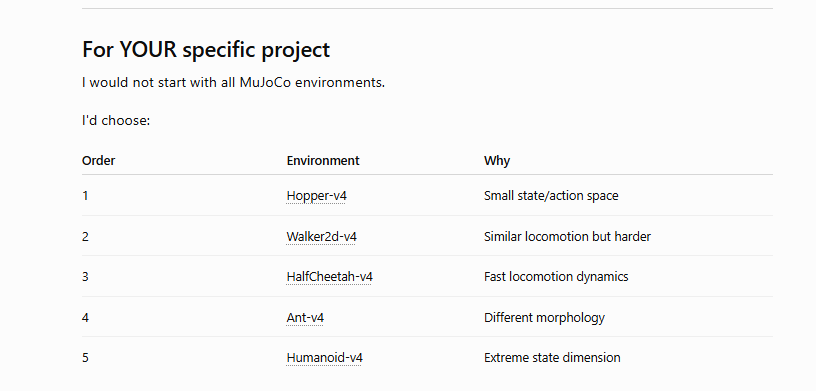

In [ ]:
actual_rollouts = cfgs.maximum_training_steps // (cfgs.total_envs * cfgs.max_rollout)
per_rollout_updates = ((cfgs.max_rollout * cfgs.total_envs) // cfgs.batch_size) * cfgs.epochs
total_optimizer_updates = actual_rollouts * per_rollout_updates  # = 5120 * 18 = 92160
print(f'> total_rollouts: {actual_rollouts}')
print(f'> per_rollout_update_count: {per_rollout_updates}')
print(f'> total_optimizer_updates: {total_optimizer_updates}')

In [ ]:
actor_lr_schedule = optax.linear_schedule(
    init_value = cfgs.actor_learning_rate,
    end_value = 2e-4,
    transition_steps = total_optimizer_updates,
)

In [ ]:
actor_optimizer = optax.chain(optax.clip_by_global_norm(0.25), optax.adam(learning_rate=actor_lr_schedule))
actor_opt_state = actor_optimizer.init(actor_variables['params'])

hopper_critic_optimizer = optax.chain(optax.clip_by_global_norm(0.5), optax.adam(learning_rate=cfgs.critic_learning_rate))
hopper_critic_opt_state = hopper_critic_optimizer.init(hopper_critic_variables['params'])

walker_critic_optimizer = optax.chain(optax.clip_by_global_norm(0.5), optax.adam(learning_rate=cfgs.critic_learning_rate))
walker_critic_opt_state = walker_critic_optimizer.init(walker_critic_variables['params'])

half_chetah_optimizer = optax.chain(optax.clip_by_global_norm(0.5), optax.adam(learning_rate=cfgs.critic_learning_rate))
half_chetah_opt_state = half_chetah_optimizer.init(half_chetah_critic_variables['params'])

In [ ]:
actor_state = TrainState(
    step = 0,
    apply_fn = actor.apply,
    params = actor_variables['params'],
    tx = actor_optimizer,
    opt_state = actor_opt_state,
)

walker_critic_state = TrainState(
    step = 0,
    apply_fn = walker_critic.apply,
    params = walker_critic_variables['params'],
    tx = walker_critic_optimizer,
    opt_state = walker_critic_opt_state,
)

hopper_critic_state = TrainState(
    step = 0,
    apply_fn = hopper_critic.apply,
    params = hopper_critic_variables['params'],
    tx = hopper_critic_optimizer,
    opt_state = hopper_critic_opt_state,
)

half_chetah_critic_state = TrainState(
    step = 0,
    apply_fn = half_chetah_critic.apply,
    params = half_chetah_critic_variables['params'],
    tx = half_chetah_optimizer,
    opt_state = half_chetah_opt_state,
)

In [ ]:
key_hopper = jax.random.PRNGKey(0)
key_walker = jax.random.PRNGKey(1)
key_half_cheetah = jax.random.PRNGKey(2)

In [ ]:
def GAE_calculation(all_states, all_next_states, all_rewards, all_dones, critic_states):

    V_st = critic_states.apply_fn(variables = {'params': critic_states.params}, x = all_states).squeeze(-1)
    V_st_next = critic_states.apply_fn(variables = {'params': critic_states.params}, x = all_next_states).squeeze(-1)

    delta = (all_rewards + cfgs.reward_decay*V_st_next*(1-all_dones.astype(jnp.float32))) - V_st

    delta_T = delta.T
    done_T = all_dones.T

    def step(carry, xs):
      delta_t, done_t = xs
      gae_t = delta_t + cfgs.gae_alpha * cfgs.reward_decay * carry * (1.0 - done_t)
      carry = gae_t
      return carry, gae_t

    _, GAE_rev = jax.lax.scan(
        step,
        jnp.zeros((delta.shape[0],), dtype=jnp.float32),  # one carry per env
        xs = (delta_T[::-1], done_T[::-1])
    )

    GAE = GAE_rev[::-1].T

    target_returns = GAE + V_st

    GAE = (GAE - jnp.mean(GAE)) / (jnp.std(GAE) + 1e-8) # nomralised gae

    GAE = jax.lax.stop_gradient(GAE)
    target_returns = jax.lax.stop_gradient(target_returns)

    return GAE, target_returns

GAE_calculation_jitted = jax.jit(GAE_calculation)

In [ ]:
epoch_key = jax.random.PRNGKey(0)
epoch_key

In [ ]:
GLOBAL_STEPS: int = 0

In [ ]:
# mean = jnp.array([0.3, 0.5, 0.98, -0.25])
# std = jnp.array([0.1, 0.05, 0.2, 1.5])

# dist = distrax.Normal(loc=mean, scale=std)

# action = dist.sample(seed=key)
# dist.prob(action), action

In [ ]:
print(cfgs.max_rollout)

In [ ]:
def get_action(mean, stds, key):
  base_dist = distrax.MultivariateNormalDiag(mean, stds)
  policy_dist = distrax.Transformed(distribution = base_dist, bijector = distrax.Block(distrax.Tanh(), ndims=1))
  squashed_action, squashed_log_probs = policy_dist.sample_and_log_prob(seed=key)
  return squashed_action, squashed_log_probs

In [ ]:
def evaluate(rec_video = False, running_hopper_mean=None, running_hopper_var=None, running_walker_mean=None, running_walker_var=None, running_half_chetah_mean=None, running_half_chetah_var=None):

  score_board = {
      cfgs.game_ids[0]: 0, cfgs.game_ids[1]: 0, cfgs.game_ids[2]: 0
      }

  for ids in cfgs.game_ids:
    envs = gym.make(ids, render_mode = 'rgb_array')

    if rec_video:
      video_dir = f"videos/{int(time.time())}"
      envs = RecordVideo(envs, video_folder=video_dir, episode_trigger=lambda ep: True)

    for _ in range(cfgs.total_evals_loop):

      done = False

      current_states, info = envs.reset()

      while not done:

        # Normalize current_states based on game_id using running mean and var
        if running_hopper_mean is not None and ids == cfgs.game_ids[0]:
            current_states = (current_states - running_hopper_mean) / jnp.sqrt(running_hopper_var + 1e-8)
        elif running_walker_mean is not None and ids == cfgs.game_ids[1]:
            current_states = (current_states - running_walker_mean) / jnp.sqrt(running_walker_var + 1e-8)
        elif running_half_chetah_mean is not None and ids == cfgs.game_ids[2]:
            current_states = (current_states - running_half_chetah_mean) / jnp.sqrt(running_half_chetah_var + 1e-8)

        current_states = jnp.concatenate([current_states, jnp.zeros((cfgs.adapter_input_dim - current_states.shape[-1]))], axis = -1)

        hopper_mean, _ , walker_mean, _, half_chetah_mean, _ = actor_state.apply_fn(
            {'params': actor_state.params}, current_states, current_states, current_states
            )

        if ids == cfgs.game_ids[0]:
          action = jnp.tanh(hopper_mean)

        if ids == cfgs.game_ids[1]:
          action = jnp.tanh(walker_mean)

        if ids == cfgs.game_ids[2]:
          action = jnp.tanh(half_chetah_mean)

        next_step, reward, terminated, truncated, _ = envs.step(np.array(action))

        done = terminated or truncated

        score_board[ids] += reward

        current_states = next_step

    if runs is not None:
      runs.log(
          {
              f"{ids}_eval_score": score_board[ids] / cfgs.total_evals_loop
          },step=GLOBAL_STEPS)
    envs.close()

In [ ]:
def get_actor_loss_unwrapped(
    params,
    hopper_states, hopper_old_actions, hopper_old_log_probs, hopper_mb_GAE,
    walker_states, walker_old_actions, walker_old_log_probs, walker_mb_GAE,
    half_chetah_states, half_chetah_old_actions, half_chetah_old_log_probs, half_chetah_mb_GAE,
    actor_model # Changed from actor_apply_fn
    ):

    hopper_mean, hopper_std, walker_mean, walker_std, half_chetah_mean, half_chetah_std  = actor_model.apply(
        variables = {'params': params}, hopper_state = hopper_states, walker_state = walker_states, half_chetah_state=half_chetah_states
    )

    hopper_base_dist = distrax.MultivariateNormalDiag(hopper_mean, hopper_std)
    hopper_policy_dist = distrax.Transformed(distribution = hopper_base_dist, bijector = distrax.Block(distrax.Tanh(), ndims=1))

    walker_base_dist = distrax.MultivariateNormalDiag(walker_mean, walker_std)
    walker_policy_dist = distrax.Transformed(distribution = walker_base_dist, bijector = distrax.Block(distrax.Tanh(), ndims=1))

    half_chetah_base_dist = distrax.MultivariateNormalDiag(half_chetah_mean, half_chetah_std)
    half_chetah_policy_dist = distrax.Transformed(distribution = half_chetah_base_dist, bijector = distrax.Block(distrax.Tanh(), ndims=1))

    hopper_log_probs = hopper_policy_dist.log_prob(hopper_old_actions)
    walker_log_probs = walker_policy_dist.log_prob(walker_old_actions)
    half_chetah_log_probs = half_chetah_policy_dist.log_prob(half_chetah_old_actions)

    hopper_clipped_log_ratio = jnp.clip(hopper_log_probs - hopper_old_log_probs, -10.0, 10.0)
    walker_clipped_log_ratio = jnp.clip(walker_log_probs - walker_old_log_probs, -10.0, 10.0)
    half_chetah_clipped_log_ratio = jnp.clip(half_chetah_log_probs - half_chetah_old_log_probs, -10.0, 10.0)

    hopper_ratio = jnp.exp(hopper_clipped_log_ratio)
    walker_ratio = jnp.exp(walker_clipped_log_ratio)
    half_chetah_ratio = jnp.exp(half_chetah_clipped_log_ratio)

    hopper_entropy = hopper_base_dist.entropy().mean()
    walker_entropy = walker_base_dist.entropy().mean()
    half_chetah_entropy = half_chetah_base_dist.entropy().mean()

    hopper_policy_loss = - jnp.minimum(hopper_ratio * hopper_mb_GAE, jnp.clip(hopper_ratio, 1 - cfgs.clip_ratio, 1 + cfgs.clip_ratio) * hopper_mb_GAE).mean()
    walker_policy_loss = - jnp.minimum(walker_ratio * walker_mb_GAE, jnp.clip(walker_ratio, 1 - cfgs.clip_ratio, 1 + cfgs.clip_ratio) * walker_mb_GAE).mean()
    half_chetah_policy_loss = - jnp.minimum(half_chetah_ratio * half_chetah_mb_GAE, jnp.clip(half_chetah_ratio, 1 - cfgs.clip_ratio, 1 + cfgs.clip_ratio) * half_chetah_mb_GAE).mean()

    entropy_loss = (hopper_entropy + walker_entropy + half_chetah_entropy) / 3.0
    policy_loss = (hopper_policy_loss + walker_policy_loss + half_chetah_policy_loss) / 3.0

    final_loss = policy_loss - (cfgs.entropy_alpha * entropy_loss)

    hopper_kl_divergence = (hopper_old_log_probs - hopper_log_probs).mean()
    walker_kl_divergence = (walker_old_log_probs - walker_log_probs).mean()
    half_chetah_kl_divergence = (half_chetah_old_log_probs - half_chetah_log_probs).mean()


    return final_loss, (hopper_kl_divergence, walker_kl_divergence, half_chetah_kl_divergence, hopper_entropy, walker_entropy, half_chetah_entropy)

jitted_actor_loss_and_grad = jax.jit(jax.value_and_grad(get_actor_loss_unwrapped, has_aux=True, argnums=0), static_argnums=13)

In [ ]:
def get_critic_loss(critic_states, mb_states, mb_target_returns):
  V_st = critic_states.apply_fn(variables = {'params': critic_states.params}, x = mb_states)
  critic_loss = optax.squared_error(V_st, mb_target_returns).mean()
  return critic_loss
jitted_critic_loss = jax.jit(get_critic_loss)

In [ ]:
# Get initial state from environment reset
hopper_current_states, info = hopper_env.reset(seed = cfgs.SEED) # This current_states is what should be passed to actor_state.apply_fn
walker_current_states, info = walker_env.reset(seed = cfgs.SEED) # This current_states is what should be passed to actor_state.apply_fn
half_chetah_current_states, info = half_chetah_env.reset(seed = cfgs.SEED) # This current_states is what should be passed to actor_state.apply_fn

In [ ]:
def get_flatten(states, rewards, actions, next_states, dones, log_probs):
  flatten_states = states.reshape(-1, states.shape[-1])
  flatten_rewards = rewards.reshape(-1)
  flatten_actions = actions.reshape(-1, actions.shape[-1])
  flatten_next_states = next_states.reshape(-1, next_states.shape[-1])
  flatten_dones = dones.reshape(-1)
  flatten_log_probs = log_probs.flatten() # Changed from reshape(-1, log_probs.shape[-1])
  return flatten_states, flatten_rewards, flatten_actions, flatten_next_states, flatten_dones, flatten_log_probs

In [ ]:
eval_key = jax.random.PRNGKey(0)

In [ ]:
hopper_running_reward = jnp.zeros((cfgs.total_envs,))
walker_running_reward = jnp.zeros((cfgs.total_envs, ))
half_chetah_running_reward = jnp.zeros((cfgs.total_envs, ))

In [ ]:
alpha = 0.98

running_hopper_mean = None
running_hopper_var = None

running_walker_mean = None
running_walker_var = None

running_half_chetah_mean = None
running_half_chetah_var = None

In [ ]:
# ── warm-up: 500 random steps to initialise normalisation stats ──
print("Running normalisation warm-up...")
hopper_env.reset(seed=cfgs.SEED)
walker_env.reset(seed=cfgs.SEED)
half_chetah_env.reset(seed=cfgs.SEED)

for _ in range(500):
    h_obs, _, _, _, _ = hopper_env.step(hopper_env.action_space.sample())
    w_obs, _, _, _, _ = walker_env.step(walker_env.action_space.sample())
    hc_obs, _, _, _, _ = half_chetah_env.step(half_chetah_env.action_space.sample())

    if running_hopper_mean is None:
        running_hopper_mean      = h_obs.mean(0);  running_hopper_var      = h_obs.var(0)  + 1e-4
        running_walker_mean      = w_obs.mean(0);  running_walker_var      = w_obs.var(0)  + 1e-4
        running_half_chetah_mean = hc_obs.mean(0); running_half_chetah_var = hc_obs.var(0) + 1e-4
    else:
        running_hopper_mean      = alpha*running_hopper_mean      + (1-alpha)*h_obs.mean(0)
        running_hopper_var       = alpha*running_hopper_var       + (1-alpha)*h_obs.var(0)
        running_walker_mean      = alpha*running_walker_mean      + (1-alpha)*w_obs.mean(0)
        running_walker_var       = alpha*running_walker_var       + (1-alpha)*w_obs.var(0)
        running_half_chetah_mean = alpha*running_half_chetah_mean + (1-alpha)*hc_obs.mean(0)
        running_half_chetah_var  = alpha*running_half_chetah_var  + (1-alpha)*hc_obs.var(0)

# reset envs back to a clean state before real training
hopper_current_states, _      = hopper_env.reset(seed=cfgs.SEED)
walker_current_states, _      = walker_env.reset(seed=cfgs.SEED)
half_chetah_current_states, _ = half_chetah_env.reset(seed=cfgs.SEED)
print("Warm-up done. Starting training.")
# ─────────────────────────────────────────────────────────────────

In [ ]:
while GLOBAL_STEPS < cfgs.maximum_training_steps:

    hopper_all_states, hopper_all_rewards, hopper_all_actions, hopper_all_next_states, hopper_all_dones, hopper_all_log_probs = [], [], [], [], [], []
    walker_all_states, walker_all_rewards, walker_all_actions, walker_all_next_states, walker_all_dones, walker_all_log_probs = [], [], [], [], [], []
    half_chetah_all_states, half_chetah_all_rewards, half_chetah_all_actions, half_chetah_all_next_states, half_chetah_all_dones, half_chetah_all_log_probs = [], [], [], [], [], []

    running_step = 0

    while running_step < cfgs.max_rollout:

        if running_hopper_mean is None:
            running_hopper_mean      = jnp.mean(hopper_current_states, axis=0)
            running_hopper_var       = jnp.var(hopper_current_states, axis=0)
            running_walker_mean      = jnp.mean(walker_current_states, axis=0)
            running_walker_var       = jnp.var(walker_current_states, axis=0)
            running_half_chetah_mean = jnp.mean(half_chetah_current_states, axis=0)
            running_half_chetah_var  = jnp.var(half_chetah_current_states, axis=0)
        else:
            running_hopper_mean      = alpha * running_hopper_mean + (1 - alpha) * jnp.mean(hopper_current_states, axis=0)
            running_hopper_var       = alpha * running_hopper_var + (1 - alpha) * jnp.var(hopper_current_states, axis=0)
            running_walker_mean      = alpha * running_walker_mean + (1 - alpha) * jnp.mean(walker_current_states, axis=0)
            running_walker_var       = alpha * running_walker_var + (1 - alpha) * jnp.var(walker_current_states, axis=0)
            running_half_chetah_mean = alpha * running_half_chetah_mean + (1 - alpha) * jnp.mean(half_chetah_current_states, axis=0)
            running_half_chetah_var  = alpha * running_half_chetah_var + (1 - alpha) * jnp.var(half_chetah_current_states, axis=0)

        # normalising states:
        hopper_current_states_norm      = (hopper_current_states - running_hopper_mean) / jnp.sqrt(running_hopper_var + 1e-8)
        walker_current_states_norm      = (walker_current_states - running_walker_mean) / jnp.sqrt(running_walker_var + 1e-8)
        half_chetah_current_states_norm = (half_chetah_current_states - running_half_chetah_mean) / jnp.sqrt(running_half_chetah_var + 1e-8)

        # Pad the current states to match the adapter's expected input dimension
        padded_hopper_current_states = jnp.concatenate(
            [
                hopper_current_states_norm,
                jnp.zeros((hopper_current_states_norm.shape[0], cfgs.adapter_input_dim - hopper_current_states_norm.shape[-1]))
            ],
            axis=-1
        )

        padded_walker_current_states = jnp.concatenate(
            [
                walker_current_states_norm,
                jnp.zeros((walker_current_states_norm.shape[0], cfgs.adapter_input_dim - walker_current_states_norm.shape[-1]))
            ],
            axis=-1
        )

        padded_half_chetah_current_states = jnp.concatenate(
            [
                half_chetah_current_states_norm,
                jnp.zeros((half_chetah_current_states_norm.shape[0], cfgs.adapter_input_dim - half_chetah_current_states_norm.shape[-1]))
            ],
            axis=-1
        )

        # Pass the current batch of padded states to the actor
        (
            hopper_mean, hopper_std,
            walker_mean, walker_std,
            half_chetah_mean, half_chetah_std
        ) = actor_state.apply_fn(
            {'params': actor_state.params},
            padded_hopper_current_states,
            padded_walker_current_states,
            padded_half_chetah_current_states
        )

        key, hopper_subkey, walker_subkey, half_chetah_subkey = jax.random.split(key, 4)

        hopper_squashed_action, hopper_squashed_log_probs = get_action(hopper_mean, hopper_std, hopper_subkey)
        walker_squashed_action, walker_squashed_log_probs = get_action(walker_mean, walker_std, walker_subkey)
        half_chetah_squashed_action, half_chetah_squashed_log_probs = get_action(half_chetah_mean, half_chetah_std, half_chetah_subkey)

        # Take a step in the environment
        hopper_next_states, hopper_reward, hopper_terminated, hopper_truncated, _ = hopper_env.step(np.array(hopper_squashed_action))
        walker_next_states, walker_reward, walker_terminated, walker_truncated, _ = walker_env.step(np.array(walker_squashed_action))
        half_chetah_next_states, half_chetah_reward, half_chetah_terminated, half_chetah_truncated, _ = half_chetah_env.step(np.array(half_chetah_squashed_action))

        # Note: These lines should likely be removed or handled differently if running_mean/var are meant to be global stats
        # For now, keeping them as per original code for next_states, but usually states and next_states should be normalized consistently.
        hopper_next_states_norm = (hopper_next_states - running_hopper_mean) / jnp.sqrt(running_hopper_var + 1e-8)
        walker_next_states_norm = (walker_next_states - running_walker_mean) / jnp.sqrt(running_walker_var + 1e-8)
        half_chetah_next_states_norm = (half_chetah_next_states - running_half_chetah_mean) / jnp.sqrt(running_half_chetah_var + 1e-8)

        hopper_running_reward += hopper_reward
        walker_running_reward += walker_reward
        half_chetah_running_reward += half_chetah_reward

        done_hopper = hopper_terminated | hopper_truncated
        done_walker = walker_terminated | walker_truncated
        done_half_chetah = half_chetah_terminated | half_chetah_truncated

        for idx in range(cfgs.total_envs):
            if done_hopper[idx] == True:
                if runs is not None:
                    runs.log({"hopper-training-reward": hopper_running_reward[idx]}, step=GLOBAL_STEPS)
                hopper_running_reward = hopper_running_reward.at[idx].set(0)

            if done_walker[idx] == True:
                if runs is not None:
                    runs.log({"walker-training-reward": walker_running_reward[idx]}, step=GLOBAL_STEPS)
                walker_running_reward = walker_running_reward.at[idx].set(0)

            if done_half_chetah[idx] == True:
                if runs is not None:
                    runs.log({"half-chetah-training-reward": half_chetah_running_reward[idx]}, step=GLOBAL_STEPS)
                half_chetah_running_reward = half_chetah_running_reward.at[idx].set(0)

        hopper_all_states.append(padded_hopper_current_states)
        hopper_all_rewards.append(jnp.array(hopper_reward, dtype=jnp.float32))
        hopper_all_actions.append(hopper_squashed_action)
        hopper_all_next_states.append(
            jnp.concatenate(
                [
                    hopper_next_states_norm,
                    jnp.zeros((hopper_next_states.shape[0], cfgs.adapter_input_dim - hopper_next_states.shape[-1]))
                ],
                axis=-1
            )
        )
        hopper_all_dones.append(jnp.array(done_hopper, dtype=jnp.float32))
        hopper_all_log_probs.append(hopper_squashed_log_probs)

        walker_all_states.append(padded_walker_current_states)
        walker_all_rewards.append(jnp.array(walker_reward, dtype=jnp.float32))
        walker_all_actions.append(walker_squashed_action)
        walker_all_next_states.append(
            jnp.concatenate(
                [
                    walker_next_states_norm,
                    jnp.zeros((walker_next_states.shape[0], cfgs.adapter_input_dim - walker_next_states.shape[-1]))
                ],
                axis=-1
            )
        )
        walker_all_dones.append(jnp.array(done_walker, dtype=jnp.float32))
        walker_all_log_probs.append(walker_squashed_log_probs)

        half_chetah_all_states.append(padded_half_chetah_current_states)
        half_chetah_all_rewards.append(jnp.array(half_chetah_reward, dtype=jnp.float32))
        half_chetah_all_actions.append(half_chetah_squashed_action)
        half_chetah_all_next_states.append(
            jnp.concatenate(
                [
                    half_chetah_next_states_norm,
                    jnp.zeros((half_chetah_next_states.shape[0], cfgs.adapter_input_dim - half_chetah_next_states.shape[-1]))
                ],
                axis=-1
            )
        )
        half_chetah_all_dones.append(jnp.array(done_half_chetah, dtype=jnp.float32))
        half_chetah_all_log_probs.append(half_chetah_squashed_log_probs)

        hopper_current_states = hopper_next_states
        walker_current_states = walker_next_states
        half_chetah_current_states = half_chetah_next_states

        if GLOBAL_STEPS % cfgs.evaluation_steps == 0 and GLOBAL_STEPS > 0:
            evaluate(rec_video=False, running_hopper_mean=running_hopper_mean, running_hopper_var=running_hopper_var, \
                     running_walker_mean=running_walker_mean, running_walker_var=running_walker_var, \
                     running_half_chetah_mean=running_half_chetah_mean, running_half_chetah_var=running_half_chetah_var)
        running_step += 1
        GLOBAL_STEPS += cfgs.total_envs

    # Convert lists of arrays to single JAX arrays for easier processing later

    hopper_all_states = jnp.array(hopper_all_states).transpose(1, 0, 2)
    hopper_all_rewards = jnp.array(hopper_all_rewards).transpose(1, 0)
    hopper_all_actions = jnp.array(hopper_all_actions).transpose(1, 0, 2)
    hopper_all_next_states = jnp.array(hopper_all_next_states).transpose(1, 0, 2)
    hopper_all_dones = jnp.array(hopper_all_dones).transpose(1, 0)
    hopper_all_log_probs = jnp.array(hopper_all_log_probs).transpose(1, 0)

    walker_all_states = jnp.array(walker_all_states).transpose(1, 0, 2)
    walker_all_rewards = jnp.array(walker_all_rewards).transpose(1, 0)
    walker_all_actions = jnp.array(walker_all_actions).transpose(1, 0, 2)
    walker_all_next_states = jnp.array(walker_all_next_states).transpose(1, 0, 2)
    walker_all_dones = jnp.array(walker_all_dones).transpose(1, 0)
    walker_all_log_probs = jnp.array(walker_all_log_probs).transpose(1, 0)

    half_chetah_all_states = jnp.array(half_chetah_all_states).transpose(1, 0, 2)
    half_chetah_all_rewards = jnp.array(half_chetah_all_rewards).transpose(1, 0)
    half_chetah_all_actions = jnp.array(half_chetah_all_actions).transpose(1, 0, 2)
    half_chetah_all_next_states = jnp.array(half_chetah_all_next_states).transpose(1, 0, 2)
    half_chetah_all_dones = jnp.array(half_chetah_all_dones).transpose(1, 0)
    half_chetah_all_log_probs = jnp.array(half_chetah_all_log_probs).transpose(1, 0)

    GAE_hopper, hopper_target_returns = GAE_calculation_jitted(
        hopper_all_states, hopper_all_next_states, hopper_all_rewards, hopper_all_dones, hopper_critic_state
    )
    GAE_walker, walker_target_returns = GAE_calculation_jitted(
        walker_all_states, walker_all_next_states, walker_all_rewards, walker_all_dones, walker_critic_state
    )
    GAE_half_chetah, half_chetah_target_returns = GAE_calculation_jitted(
        half_chetah_all_states, half_chetah_all_next_states, half_chetah_all_rewards, half_chetah_all_dones, half_chetah_critic_state
    )

    flatten_walker_states, flatten_walker_reward, flatten_walker_action, flatten_walker_nxt_state, flatten_walker_dones, flatten_walker_log_probs = get_flatten(
        walker_all_states, walker_all_rewards, walker_all_actions, walker_all_next_states, walker_all_dones, walker_all_log_probs
    )
    flatten_hopper_states, flatten_hopper_reward, flatten_hopper_action, flatten_hopper_nxt_state, flatten_hopper_dones, flatten_hopper_log_probs = get_flatten(
        hopper_all_states, hopper_all_rewards, hopper_all_actions, hopper_all_next_states, hopper_all_dones, hopper_all_log_probs
    )
    flatten_half_chetah_states, flatten_half_chetah_reward, flatten_half_chetah_action, flatten_half_chetah_nxt_state, flatten_half_chetah_dones, flatten_half_chetah_log_probs = get_flatten(
        half_chetah_all_states, half_chetah_all_rewards, half_chetah_all_actions, half_chetah_all_next_states, half_chetah_all_dones, half_chetah_all_log_probs
    )

    total_transition = flatten_hopper_states.shape[0]

    for epoch in range(cfgs.epochs):

        epoch_key, epoch_sub_key = jax.random.split(epoch_key, 2)
        permutation = jax.random.permutation(epoch_sub_key, total_transition)

        logging_step = 0
        logging_actor_loss = 0
        logging_hopper_critic_loss = 0
        logging_walker_critic_loss = 0
        logging_half_chetah_critic_loss = 0

        logging_hopper_kl_divergence = 0
        logging_walker_kl_divergence = 0
        logging_half_chetah_kl_divergence = 0

        logging_hopper_entropy = 0
        logging_walker_entropy = 0
        logging_half_chetah_entropy = 0

        for idx in range(0, total_transition, cfgs.batch_size):

            curr_batch_idx = permutation[idx:idx + cfgs.batch_size]

            walker_mb_states = flatten_walker_states[curr_batch_idx]
            walker_mb_reward = flatten_walker_reward[curr_batch_idx]
            walker_mb_action = flatten_walker_action[curr_batch_idx].astype(jnp.float32)
            walker_mb_nxt_state = flatten_walker_nxt_state[curr_batch_idx]
            walker_mb_dones = flatten_walker_dones[curr_batch_idx]
            walker_mb_log_probs = flatten_walker_log_probs[curr_batch_idx].astype(jnp.float32)
            walker_mb_GAE = GAE_walker.flatten()[curr_batch_idx].astype(jnp.float32)
            walker_mb_target_returns = walker_target_returns.flatten()[curr_batch_idx]

            hopper_mb_states = flatten_hopper_states[curr_batch_idx]
            hopper_mb_reward = flatten_hopper_reward[curr_batch_idx]
            hopper_mb_action = flatten_hopper_action[curr_batch_idx].astype(jnp.float32)
            hopper_mb_nxt_state = flatten_hopper_nxt_state[curr_batch_idx]
            hopper_mb_dones = flatten_hopper_dones[curr_batch_idx]
            hopper_mb_log_probs = flatten_hopper_log_probs[curr_batch_idx].astype(jnp.float32)
            hopper_mb_GAE = GAE_hopper.flatten()[curr_batch_idx].astype(jnp.float32)
            hopper_mb_target_returns = hopper_target_returns.flatten()[curr_batch_idx]

            half_chetah_mb_states = flatten_half_chetah_states[curr_batch_idx]
            half_chetah_mb_reward = flatten_half_chetah_reward[curr_batch_idx]
            half_chetah_mb_action = flatten_half_chetah_action[curr_batch_idx].astype(jnp.float32)
            half_chetah_mb_nxt_state = flatten_half_chetah_nxt_state[curr_batch_idx]
            half_chetah_mb_dones = flatten_half_chetah_dones[curr_batch_idx]
            half_chetah_mb_log_probs = flatten_half_chetah_log_probs[curr_batch_idx].astype(jnp.float32)
            half_chetah_mb_GAE = GAE_half_chetah.flatten()[curr_batch_idx].astype(jnp.float32)
            half_chetah_mb_target_returns = half_chetah_target_returns.flatten()[curr_batch_idx]

            # =============== for actor-update ===============
            (
                actor_loss,
                (
                    hopper_kl_divergence,
                    walker_kl_divergence,
                    half_chetah_kl_divergence,
                    hopper_entropy,
                    walker_entropy,
                    half_chetah_entropy
                )
            ), actor_grad = jitted_actor_loss_and_grad(
                actor_state.params,
                hopper_mb_states, hopper_mb_action, hopper_mb_log_probs, hopper_mb_GAE,
                walker_mb_states, walker_mb_action, walker_mb_log_probs, walker_mb_GAE,
                half_chetah_mb_states, half_chetah_mb_action, half_chetah_mb_log_probs, half_chetah_mb_GAE,
                actor
            )

            actor_state = actor_state.apply_gradients(grads=actor_grad)

            # =============== for critic-update ===============
            def hopper_critic_loss_fn(params):
                v_pred = hopper_critic_state.apply_fn({'params': params}, x=hopper_mb_states).squeeze(-1)
                return optax.squared_error(v_pred, hopper_mb_target_returns).mean()

            def walker_critic_loss_fn(params):
                v_pred = walker_critic_state.apply_fn({'params': params}, x=walker_mb_states).squeeze(-1)
                return optax.squared_error(v_pred, walker_mb_target_returns).mean()

            def half_chetah_critic_loss_fn(params):
                v_pred = half_chetah_critic_state.apply_fn({'params': params}, x=half_chetah_mb_states).squeeze(-1)
                return optax.squared_error(v_pred, half_chetah_mb_target_returns).mean()

            hopper_critic_loss, hopper_critic_grads = jax.value_and_grad(hopper_critic_loss_fn)(hopper_critic_state.params)
            hopper_critic_state = hopper_critic_state.apply_gradients(grads=hopper_critic_grads)

            walker_critic_loss, walker_critic_grads = jax.value_and_grad(walker_critic_loss_fn)(walker_critic_state.params)
            walker_critic_state = walker_critic_state.apply_gradients(grads=walker_critic_grads)

            half_chetah_critic_loss, half_chetah_critic_grads = jax.value_and_grad(half_chetah_critic_loss_fn)(half_chetah_critic_state.params)
            half_chetah_critic_state = half_chetah_critic_state.apply_gradients(grads=half_chetah_critic_grads)

            logging_step += 1
            logging_actor_loss += actor_loss

            logging_hopper_critic_loss += hopper_critic_loss
            logging_walker_critic_loss += walker_critic_loss
            logging_half_chetah_critic_loss += half_chetah_critic_loss

            logging_hopper_kl_divergence += hopper_kl_divergence
            logging_walker_kl_divergence += walker_kl_divergence
            logging_half_chetah_kl_divergence += half_chetah_kl_divergence

            logging_hopper_entropy += hopper_entropy
            logging_walker_entropy += walker_entropy
            logging_half_chetah_entropy += half_chetah_entropy

        if runs is not None:
            runs.log(
                {
                    "actor_loss": logging_actor_loss / logging_step,

                    "hopper_critic_loss": logging_hopper_critic_loss / logging_step,
                    "walker_critic_loss": logging_walker_critic_loss / logging_step,
                    "half_chetah_critic_loss": logging_half_chetah_critic_loss / logging_step,

                    "hopper_kl_divergence": logging_hopper_kl_divergence / logging_step,
                    "walker_kl_divergence": logging_walker_kl_divergence / logging_step,
                    "half_chetah_kl_divergence": logging_half_chetah_kl_divergence / logging_step,

                    "hopper_entropy": logging_hopper_entropy / logging_step,
                    "walker_entropy": logging_walker_entropy / logging_step,
                    "half_chetah_entropy": logging_half_chetah_entropy / logging_step,

                    "global_step": GLOBAL_STEPS,
                },
                step=GLOBAL_STEPS,
            )